## Single Layer Bidirectional GRU Model using word2vec (CBOW or Skipgram and any vector size from 64 to 300)

### **TEST Data Check**

| **Check**                     | **Status**               | **Details**                                                                 |
|-------------------------------|--------------------------|-----------------------------------------------------------------------------|
| Confusion Matrix Built?        | Yes        |                                   |
| F1 Score for Positive          | 0.84      | F1 score for the positive class.                                            |
| F1 Score for Negative          | 0.50      | F1 score for the negative class.                                            |
| AUC Plotted?                   | Yes               | SEE BELOW                                      |
| AUC                            |  0.82     | Area under the ROC curve.                                                   |
| Accuracy Computed?             | Yes              | If yes, provide the accuracy value.                                         |
| Accuracy                       | 0.92    | Accuracy of the model on the testing data.                                 |

---

### **Feature Engineering**

| **Check**                     | **Status**               | **Details**                                                                 |
|-------------------------------|--------------------------|-----------------------------------------------------------------------------|
| Feature Weightages Added?      | Yes               |                 |
| 2 Features with Highest Weights| Feature 1: Weight       | Word count added                          |
|                               |      |                                                                             |

---

### **Cross Validation**

| **Check**                     | **Status**               | **Details**                                                                 |
|-------------------------------|--------------------------|-----------------------------------------------------------------------------|
| Type of Cross Validation       | K-Fold (3-fold)   | CROSS VALIDATION implemented but not run. system was crashing                                 |
| Findings of Cross Validation   | Mean Accuracy: Value    |                                    |

---

### **Training Data Check**

| **Check**                     | **Status**               | **Details**                                                                 |
|-------------------------------|--------------------------|-----------------------------------------------------------------------------|
| Confusion Matrix Built?        | Yes/No                  | see below                                      |
| F1 Score for Positive          | 0.72    | F1 score for the positive class.                                            |
| F1 Score for Negative          | 0.52     | F1 score for the negative class.                                            |
| AUC Plotted?                   | Yes           | If yes, attach the ROC curve plot.                                          |
| AUC                            |  0.82  | Area under the ROC curve.                                                   |
| Accuracy Computed?             | Yes/No                  | If yes, provide the accuracy value.                                         |
| Accuracy                       | 0.73      | Accuracy of the model on the testing data.                                  |

---

### **Next Steps**

| **Check**                     | **Details**                                                                 |
|-------------------------------|-----------------------------------------------------------------------------|
| Next Steps      | 1. Adjust Hyperparameters: If performance is suboptimal, refine GRU units, dropout rate, or batch size.
Test on Unseen Data: Ensure the model generalizes well by testing on a separate dataset.            |
|                               |     |
|                               |     |

---

### **Data Preprocessing and Feature Engineering**

| **Check**                     | **Status**               |                                                               |
|-------------------------------|--------------------------|-----------------------------------------------------------------------------|
| Regex Used?                    | Yes               |                         |
| # of Regex Used                | Value (e.g., 5)         |          |
| Emoji Handling Done?           | Yes               |                              |
| # of Emojis Handled            |   all   |                                     |
| Slang Handling Done?           | Yes                |                              |
| # of Slangs Handled            | 30       |                             |
| Abbreviations Handled?         | Yes             |                       |
| #

## Import Libraries 

In [1]:
import numpy as np
import pandas as pd
import re
import emoji
from sklearn.model_selection import train_test_split, cross_val_score
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
from sklearn.preprocessing import OneHotEncoder, label_binarize
import seaborn as sns
from scikeras.wrappers import KerasClassifier 
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from functools import partial

## Load dataset

In [2]:

data = pd.read_csv("Sentiment_Data.csv", encoding="ISO-8859-1")

# Randomly sample 40,000 rows
sampled_data = data.sample(n=30000, random_state=42)  # random_state ensures reproducibility

# Extract tweets and sentiments
tweets = sampled_data["Tweet"].values

sentiments = sampled_data["Sentiment"].map({"Mild_Pos": 0, "Strong_Pos": 0, "Neutral": 1, "Mild_Neg": 2, "Strong_Neg": 2}).values

In [3]:
print(len(tweets))      
print(len(sentiments))  

30000
30000


In [4]:

data = pd.read_csv("Sentiment_Data.csv", encoding="ISO-8859-1")

# Randomly sample 40,000 rows
sampled_data = data.sample(n=30000, random_state=42)  # Ensures reproducibility

# Extract tweets
tweets = sampled_data["Tweet"].values  

# Map sentiment labels
sentiment_mapping = {"Mild_Pos": 0, "Strong_Pos": 0, "Neutral": 1, "Mild_Neg": 2, "Strong_Neg": 2}
sentiments = sampled_data["Sentiment"].map(sentiment_mapping).values  



In [5]:
# Reshape the data for OneHotEncoder
sentiments_reshaped = sentiments.reshape(-1, 1)  

# Initialize and fit OneHotEncoder
encoder = OneHotEncoder(sparse=False)  
y = encoder.fit_transform(sentiments_reshaped)

# Verify the output
print("One-hot encoded labels (y):")
print(y[:5])  # Print first 5 rows of y
print(f"Shape of y: {y.shape}")  # Should be (40000, 3)


One-hot encoded labels (y):
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
Shape of y: (30000, 3)


C:\Users\COMFORT\anaconda3\envs\new_env\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


## DATA PREPROCESSING

In [6]:
# Regex patterns
def preprocess_text(text):
    text = str(text)
    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    # Remove mentions
    text = re.sub(r"@\w+", "", text)
    # Remove hashtags
    text = re.sub(r"#\w+", "", text)
    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    # Convert to lowercase
    text = text.lower()
    return text

# Emoji handling
def handle_emojis(text):
    return emoji.demojize(text)

# Slang and abbreviation handling
slang_dict = {
    "lol": "laugh out loud",
    "lmao": "laughing my ass off",
    "rofl": "rolling on the floor laughing",
    "lmfao": "laughing my freaking ass off",
    "brb": "be right back",
    "gtg": "got to go",
    "g2g": "got to go",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "omg": "oh my god",
    "ttyl": "talk to you later",
    "tbh": "to be honest",
    "smh": "shaking my head",
    "lmk": "let me know",
    "afk": "away from keyboard",
    "ikr": "i know, right?",
    "dm": "direct message",
    "jk": "just kidding",
    "np": "no problem",
    "thx": "thanks",
    "ty": "thank you",
    "gg": "good game",
    "glhf": "good luck, have fun",
    "hf": "have fun",
    "wp": "well played",
    "wyd": "what are you doing?",
    "hmu": "hit me up",
    "fyi": "for your information",
    "bff": "best friends forever",
    "nvm": "never mind",
    "idc": "i don't care",
    "idgaf": "i don't give a freak",
    "idgad": "i don't give a damn",
    "wbu": "what about you?",
    "wym": "what you mean?",
    "icymi": "in case you missed it",
    "ftw": "for the win",
    "stfu": "shut the freak up",
    "smdh": "shaking my damn head",
    "fr": "for real",
    "frfr": "for real for real",
    "no cap": "no lie",
    "cap": "lie",
    "bet": "okay/got it",
    "lit": "amazing",
    "yeet": "to throw/discard forcefully",
    "sus": "suspicious",
    "vibe": "feeling/mood",
    "mood": "relatable emotion",
    "snacc": "attractive person",
    "goat": "greatest of all time",
    "dope": "cool",
    "flex": "show off",
    "ghosting": "ignoring someone",
    "lowkey": "kind of",
    "highkey": "definitely",
    "slaps": "really good",
    "bop": "good song",
    "simp": "person who tries too hard for someone",
    "drip": "stylish outfit",
    "big yikes": "very embarrassing",
    "wyd": "what are you doing?",
    "hbu": "how about you?",
    "wyd": "what you doing?",
    "tldr": "too long; didn't read",
    "irl": "in real life",
    "ama": "ask me anything",
    "rn": "right now",
    "b4": "before",
    "bf": "boyfriend",
    "gf": "girlfriend",
    "bae": "before anyone else",
    "ily": "i love you",
    "ilu": "i love you",
    "smol": "small and cute",
    "owo": "surprised face",
    "uwu": "happy face",
    "pov": "point of view",
    "noob": "inexperienced person",
    "rekt": "utterly defeated",
    "ggwp": "good game, well played",
    "grind": "hard work",
    "spam": "excessive messaging",
    "nerf": "reduce power (gaming)",
    "op": "overpowered",
    "npc": "non-playable character (or unoriginal person)",
    "irl": "in real life",
    "mfw": "my face when",
    "tfw": "that feeling when",
    "af": "as freak",
    "mf": "mother freaker",
    "wth": "what the heck",
    "wtf": "what the freak",
    "tmi": "too much information",
    "cya": "see you",
    "cya l8r": "see you later",
    "ttfn": "ta-ta for now",
    "bday": "birthday",
    "asap": "as soon as possible",
    "afaik": "as far as I know",
    "ik": "i know",
    "np": "no problem",
    "fomo": "fear of missing out",
    "jfc": "jesus freaking christ",
    "rn": "right now",
    "ngl": "not gonna lie",
    "dw": "don't worry",
    "hbd": "happy birthday",
    "ro": "relaxation only",
    "bc": "because",
    "acc": "actually",
    "ez": "easy",
    "thicc": "curvy or full-figured",
    "mid": "average or mediocre",
    "v": "very",
    "qt": "cutie",
    "wb": "welcome back",
    "xoxo": "hugs and kisses",
}


abbr_dict = {
    "u": "you",
    "r": "are",
    "y": "why",
    "ur": "your",
    "pls": "please",
    "plz": "please",
    "w/": "with",
    "w/o": "without",
    "nvm": "never mind",
    "tho": "though",
    "bc": "because",
    "msg": "message",
    "sry": "sorry",
    "ok": "okay",
    "k": "okay",
    "thx": "thanks",
    "ty": "thank you",
    "omw": "on my way",
    "btw": "by the way",
    "fwiw": "for what it's worth",
    "gtg": "got to go",
    "tbh": "to be honest",
    "wut": "what",
    "gg": "good game",
    "bruh": "bro",
    "bff": "best friends forever",
    "idc": "i don't care",
    "l8r": "later",
    "aight": "alright",
    "doe": "though",
    "dis": "this",
    "dat": "that",
    "wat": "what",
    "coz": "because",
    "cuz": "because",
    "dunno": "do not know",
    "tmrw": "tomorrow",
}


def handle_slangs_and_abbr(text):
    words = text.split()
    for i, word in enumerate(words):
        if word in slang_dict:
            words[i] = slang_dict[word]
        if word in abbr_dict:
            words[i] = abbr_dict[word]
    return " ".join(words)

#Apply preprocessing
tweets = [preprocess_text(tweet) for tweet in tweets]
tweets = [handle_emojis(tweet) for tweet in tweets]
tweets = [handle_slangs_and_abbr(tweet) for tweet in tweets]

## Tokenization and word2vector embeddings

In [7]:
# Tokenize tweets (on the entire dataset)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(tweets)  # Create vocabulary from all tweets
sequences = tokenizer.texts_to_sequences(tweets)  # Convert all tweets to sequences
vocab_size = len(tokenizer.word_index) + 1  # Vocabulary size

# Verify the output
print("Tokenized sequences (first 5):")
print(sequences[:5])
print(f"Vocabulary size: {vocab_size}")



Tokenized sequences (first 5):
[[597, 671, 2, 3, 9, 108, 797, 1, 1783, 16, 285, 36, 139, 671, 529, 44, 42, 3106], [2, 3, 256, 4, 7, 162, 1052, 11, 898, 623, 828, 8, 1, 66], [1, 1212, 208, 9, 12, 1, 14413, 3, 50, 819, 39, 69, 504, 121, 35, 1240, 56, 4, 4282, 2979, 4577, 2235], [465, 40, 10470, 122, 4024, 1485, 4, 394, 13, 55, 849, 1455, 4, 394, 52, 122, 109, 68, 13, 4283, 19, 77, 435, 12, 1711, 1, 2, 3, 962, 10470], [2567, 3793, 122, 2, 3, 27, 1665, 7, 2849, 1784, 45, 17, 21, 249, 74, 1, 450, 6, 802, 14414, 90, 1, 149, 208]]
Vocabulary size: 31062


In [8]:
# Pad sequences
max_len = 50
X_padded = pad_sequences(sequences, maxlen=max_len, padding="post")

# Verify the output
print("Padded sequences (first 5):")
print(X_padded[:5])
print(f"Shape of X_padded: {X_padded.shape}")

Padded sequences (first 5):
[[  597   671     2     3     9   108   797     1  1783    16   285    36
    139   671   529    44    42  3106     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [    2     3   256     4     7   162  1052    11   898   623   828     8
      1    66     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [    1  1212   208     9    12     1 14413     3    50   819    39    69
    504   121    35  1240    56     4  4282  2979  4577  2235     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0]
 [  465    40 10470   122  4024  1485  

## FEATURE ENGINEERING

In [9]:
# Add Text Length 
text_lengths = np.array([len(tweet.split()) for tweet in tweets]).reshape(-1, 1)


# Combine Features
X_combined = np.hstack((X_padded, text_lengths))


## Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (24000, 51)
Shape of X_test: (6000, 51)
Shape of y_train: (24000, 3)
Shape of y_test: (6000, 3)


## Train Word2Vec model on training data 

In [11]:
# Train Word2Vec model on training data ONLY
tokenized_tweets_train = [tweet.split() for tweet in tweets[:len(X_train)]]

# Train Word2Vec model using Skip-gram (sg=1) or CBOW (sg=0)
word2vec_model = Word2Vec(
    sentences=tokenized_tweets_train,  # Tokenized training data
    vector_size=128,                   # Set vector size between 64 and 300
    window=5,                          # Context window size
    min_count=1,                       # Ignore words with frequency < min_count
    sg=1                               # sg=1 for Skip-gram, sg=0 for CBOW
)

# Create Embedding Matrix
embedding_matrix = np.zeros((vocab_size, word2vec_model.vector_size))
for word, i in tokenizer.word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[i] = word2vec_model.wv[word]

# Verify the output
print(f"Shape of embedding matrix: {embedding_matrix.shape}")


Shape of embedding matrix: (31062, 128)


## Build the Model

In [12]:
print(vocab_size, max_len, embedding_matrix.shape)

31062 50 (31062, 128)


In [13]:
def build_model(gru_units=64, dropout_rate=0.3):
    input_layer = Input(shape=(max_len + 1,), name="input_layer")
    sequences = input_layer[:, :-1]  # Padded sequences
    text_length = input_layer[:, -1:]  # Text length feature
    
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len, 
                                weights=[embedding_matrix], trainable=True)(sequences)
    
    gru_output = Bidirectional(GRU(gru_units, return_sequences=False))(embedding_layer)
    concatenated = Concatenate()([gru_output, text_length])
    
    x = Dropout(dropout_rate)(concatenated)
    x = Dense(64, activation="relu")(x)
    output = Dense(3, activation="softmax")(x)
    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return model

# Wrap the build_model function using partial to accept parameters dynamically
model_fn = partial(build_model)

##  Train a baseline model with default hyperparameters

In [14]:
# Train a baseline model with default hyperparameters
print("Training baseline model with default hyperparameters...")
baseline_model = build_model()  # Use default GRU units (64) and dropout rate (0.3)
history = baseline_model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])



Training baseline model with default hyperparameters...
Epoch 1/20
300/300 [==============================] - 28s 83ms/step - loss: 0.8457 - accuracy: 0.6757 - val_loss: 0.7284 - val_accuracy: 0.7131
Epoch 2/20
300/300 [==============================] - 23s 75ms/step - loss: 0.6107 - accuracy: 0.7614 - val_loss: 0.6484 - val_accuracy: 0.7569
Epoch 3/20
300/300 [==============================] - 22s 73ms/step - loss: 0.3900 - accuracy: 0.8499 - val_loss: 0.6632 - val_accuracy: 0.7700
Epoch 4/20
300/300 [==============================] - 22s 73ms/step - loss: 0.2547 - accuracy: 0.9045 - val_loss: 0.7402 - val_accuracy: 0.7442
Epoch 5/20
300/300 [==============================] - 22s 72ms/step - loss: 0.1684 - accuracy: 0.9424 - val_loss: 0.9322 - val_accuracy: 0.7365


## Evaluate our baseline model on the test set

Confusion Matrix (TEST) for Baseline Model:


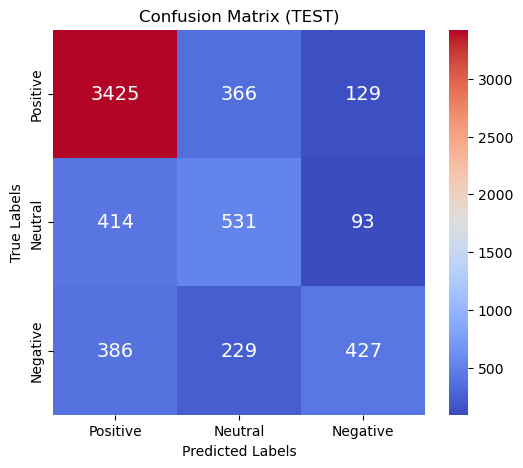

F1 Score (Weighted) (TEST): 0.7221
F1 Score (Negative) (TEST): 0.5050
AUC (TEST): 0.8259
Accuracy (TEST): 0.7305
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84      3920
           1       0.47      0.51      0.49      1038
           2       0.66      0.41      0.51      1042

    accuracy                           0.73      6000
   macro avg       0.65      0.60      0.61      6000
weighted avg       0.73      0.73      0.72      6000



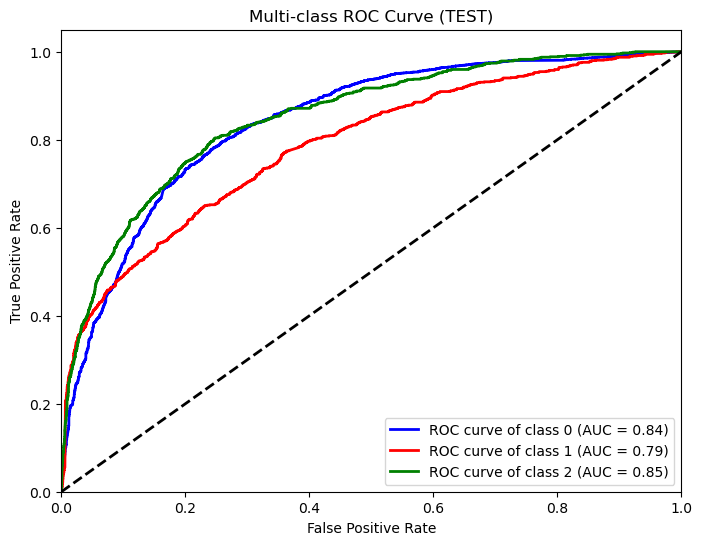

In [15]:

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=["Positive", "Neutral", "Negative"], 
                yticklabels=["Positive", "Neutral", "Negative"], annot_kws={"size": 14})
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()

# Evaluate the baseline model on the TEST set
y_pred_test = baseline_model.predict(X_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion Matrix (TEST)
cm_test = confusion_matrix(y_test_classes, y_pred_test_classes)
print("Confusion Matrix (TEST) for Baseline Model:")
plot_confusion_matrix(cm_test, "Confusion Matrix (TEST)")

# F1 Scores (TEST)
f1_weighted_test = f1_score(y_test_classes, y_pred_test_classes, average="weighted")
f1_neg_test = f1_score(y_test_classes, y_pred_test_classes, average="weighted", labels=[2])
print(f"F1 Score (Weighted) (TEST): {f1_weighted_test:.4f}")
print(f"F1 Score (Negative) (TEST): {f1_neg_test:.4f}")

# Multi-class AUC-ROC (TEST)
roc_auc_test = roc_auc_score(y_test, y_pred_test, multi_class="ovr")
print(f"AUC (TEST): {roc_auc_test:.4f}")

# Accuracy (TEST)
accuracy_test = accuracy_score(y_test_classes, y_pred_test_classes)
print(f"Accuracy (TEST): {accuracy_test:.4f}")

print("Classification Report:\n", classification_report(y_test_classes, y_pred_test_classes))

# Plot ROC curve for each class (TEST)
n_classes = y_test.shape[1]
y_test_bin = label_binarize(y_test_classes, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']  # Adjust colors as needed
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (TEST)')
plt.legend(loc="lower right")
plt.show()

print("\n" + "="*50 + "\n")




## Evaluate our baseline model on the train set

Confusion Matrix (TRAIN) for Baseline Model:


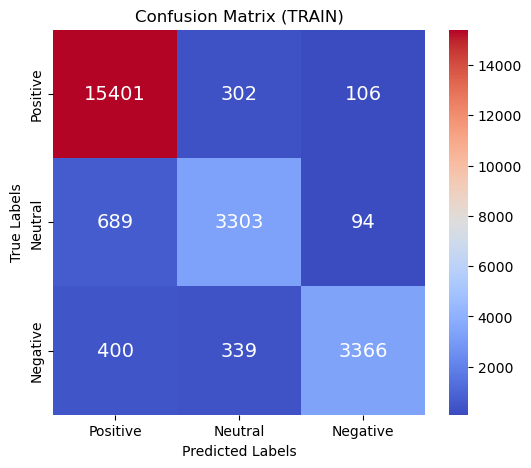

F1 Score (Weighted) (TRAIN): 0.9183
F1 Score (Negative) (TRAIN): 0.8776
AUC (TRAIN): 0.9721
Accuracy (TRAIN): 0.9196


Classification Report (TRAIN):
               precision    recall  f1-score   support

           0       0.93      0.97      0.95     15809
           1       0.84      0.81      0.82      4086
           2       0.94      0.82      0.88      4105

    accuracy                           0.92     24000
   macro avg       0.91      0.87      0.88     24000
weighted avg       0.92      0.92      0.92     24000



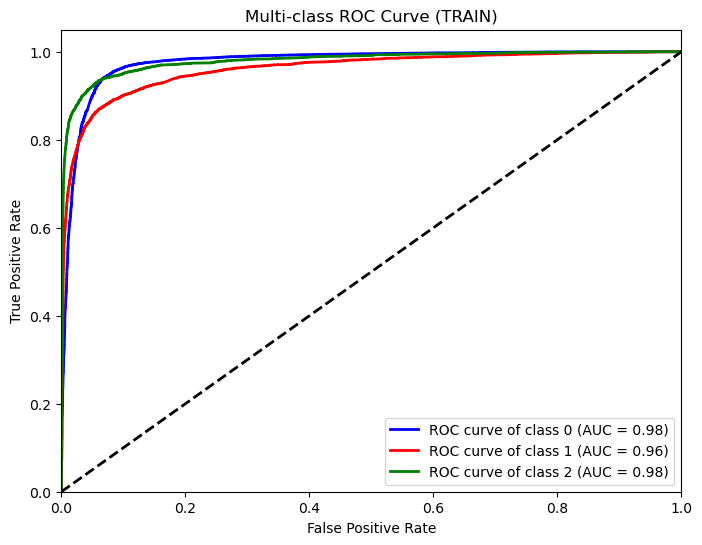

In [16]:
# Evaluate the baseline model on the TRAINING set
y_pred_train = baseline_model.predict(X_train)
y_pred_train_classes = np.argmax(y_pred_train, axis=1)
y_train_classes = np.argmax(y_train, axis=1)

# Confusion Matrix (TRAIN)
cm_train = confusion_matrix(y_train_classes, y_pred_train_classes)
print("Confusion Matrix (TRAIN) for Baseline Model:")
plot_confusion_matrix(cm_train, "Confusion Matrix (TRAIN)")

# F1 Scores (TRAIN)
f1_weighted_train = f1_score(y_train_classes, y_pred_train_classes, average="weighted")
f1_neg_train = f1_score(y_train_classes, y_pred_train_classes, average="weighted", labels=[2])
print(f"F1 Score (Weighted) (TRAIN): {f1_weighted_train:.4f}")
print(f"F1 Score (Negative) (TRAIN): {f1_neg_train:.4f}")

# Multi-class AUC-ROC (TRAIN)
roc_auc_train = roc_auc_score(y_train, y_pred_train, multi_class="ovr")
print(f"AUC (TRAIN): {roc_auc_train:.4f}")

# Accuracy (TRAIN)
accuracy_train = accuracy_score(y_train_classes, y_pred_train_classes)
print(f"Accuracy (TRAIN): {accuracy_train:.4f}")

print("\n" + "="*50 + "\n")

print("Classification Report (TRAIN):\n", classification_report(y_train_classes, y_pred_train_classes))

# Plot ROC curve for each class
n_classes = y_train.shape[1]
y_train_bin = label_binarize(y_train_classes, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_pred_train[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']  # Adjust colors as needed
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (TRAIN)')
plt.legend(loc="lower right")
plt.show()





## Hyperparameter tuning iterations 1st iteration

In [17]:
def build_model(gru_units=256, dropout_rate=0.3):
    input_layer = Input(shape=(max_len + 1,), name="input_layer")
    sequences = input_layer[:, :-1]  # Padded sequences
    text_length = input_layer[:, -1:]  # Text length feature
    
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len, 
                                weights=[embedding_matrix], trainable=True)(sequences)
    
    gru_output = Bidirectional(GRU(gru_units, return_sequences=False))(embedding_layer)
    concatenated = Concatenate()([gru_output, text_length])
    
    x = Dropout(dropout_rate)(concatenated)
    x = Dense(64, activation="relu")(x)
    output = Dense(3, activation="softmax")(x)
    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return model

# Wrap the build_model function using partial to accept parameters dynamically
model_fn = partial(build_model)

In [18]:
# Train a 1st iteration model with new hyperparameters
print("Training baseline model with different hyperparameters...")
new_model = build_model()  # (128) and dropout rate (0.3)
history = new_model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])

Training baseline model with different hyperparameters...
Epoch 1/20
300/300 [==============================] - 62s 198ms/step - loss: 0.7744 - accuracy: 0.6956 - val_loss: 0.6843 - val_accuracy: 0.7296
Epoch 2/20
300/300 [==============================] - 59s 197ms/step - loss: 0.5535 - accuracy: 0.7880 - val_loss: 0.5981 - val_accuracy: 0.7719
Epoch 3/20
300/300 [==============================] - 58s 192ms/step - loss: 0.3552 - accuracy: 0.8624 - val_loss: 0.6925 - val_accuracy: 0.7592
Epoch 4/20
300/300 [==============================] - 57s 190ms/step - loss: 0.2357 - accuracy: 0.9123 - val_loss: 0.8016 - val_accuracy: 0.7600
Epoch 5/20
300/300 [==============================] - 56s 186ms/step - loss: 0.1474 - accuracy: 0.9468 - val_loss: 1.1803 - val_accuracy: 0.7146


## Evaluation on first Iteration

Confusion Matrix (TEST) for New Iterated Model:


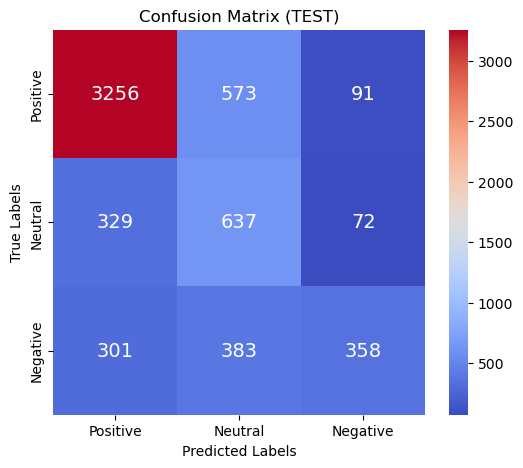

F1 Score (Weighted) (TEST): 0.7084
F1 Score (Negative) (TEST): 0.4581
AUC (TEST): 0.8211
Accuracy (TEST): 0.7085
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83      3920
           1       0.40      0.61      0.48      1038
           2       0.69      0.34      0.46      1042

    accuracy                           0.71      6000
   macro avg       0.64      0.60      0.59      6000
weighted avg       0.74      0.71      0.71      6000



Confusion Matrix (TRAIN) for new Iterated Model:


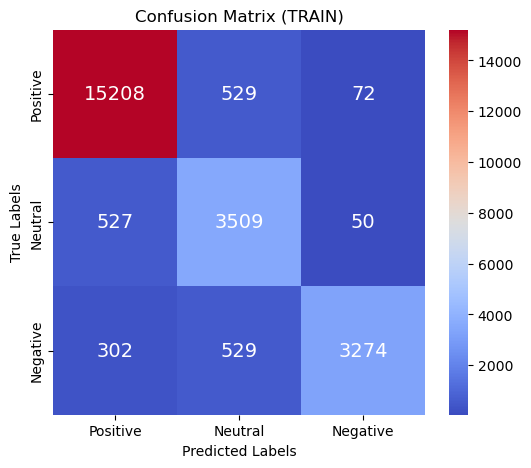

F1 Score (Weighted) (TRAIN): 0.9165
F1 Score (Negative) (TRAIN): 0.8730
AUC (TRAIN): 0.9726
Accuracy (TRAIN): 0.9163


Classification Report (TRAIN):
               precision    recall  f1-score   support

           0       0.95      0.96      0.96     15809
           1       0.77      0.86      0.81      4086
           2       0.96      0.80      0.87      4105

    accuracy                           0.92     24000
   macro avg       0.89      0.87      0.88     24000
weighted avg       0.92      0.92      0.92     24000



In [19]:

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=["Positive", "Neutral", "Negative"], 
                yticklabels=["Positive", "Neutral", "Negative"], annot_kws={"size": 14})
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()

# Evaluate the TUNED model on the TEST set
y_pred_test = new_model.predict(X_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion Matrix (TEST)
cm_test = confusion_matrix(y_test_classes, y_pred_test_classes)
print("Confusion Matrix (TEST) for New Iterated Model:")
plot_confusion_matrix(cm_test, "Confusion Matrix (TEST)")

# F1 Scores (TEST)
f1_weighted_test = f1_score(y_test_classes, y_pred_test_classes, average="weighted")
f1_neg_test = f1_score(y_test_classes, y_pred_test_classes, average="weighted", labels=[2])
print(f"F1 Score (Weighted) (TEST): {f1_weighted_test:.4f}")
print(f"F1 Score (Negative) (TEST): {f1_neg_test:.4f}")

# Multi-class AUC-ROC (TEST)
roc_auc_test = roc_auc_score(y_test, y_pred_test, multi_class="ovr")
print(f"AUC (TEST): {roc_auc_test:.4f}")

# Accuracy (TEST)
accuracy_test = accuracy_score(y_test_classes, y_pred_test_classes)
print(f"Accuracy (TEST): {accuracy_test:.4f}")

print("Classification Report:\n", classification_report(y_test_classes, y_pred_test_classes))

print("\n" + "="*50 + "\n")

# Evaluate the new iteration model on the TRAINING set
y_pred_train = new_model.predict(X_train)
y_pred_train_classes = np.argmax(y_pred_train, axis=1)
y_train_classes = np.argmax(y_train, axis=1)

# Confusion Matrix (TRAIN)
cm_train = confusion_matrix(y_train_classes, y_pred_train_classes)
print("Confusion Matrix (TRAIN) for new Iterated Model:")
plot_confusion_matrix(cm_train, "Confusion Matrix (TRAIN)")

# F1 Scores (TRAIN)
f1_weighted_train = f1_score(y_train_classes, y_pred_train_classes, average="weighted")
f1_neg_train = f1_score(y_train_classes, y_pred_train_classes, average="weighted", labels=[2])
print(f"F1 Score (Weighted) (TRAIN): {f1_weighted_train:.4f}")
print(f"F1 Score (Negative) (TRAIN): {f1_neg_train:.4f}")

# Multi-class AUC-ROC (TRAIN)
roc_auc_train = roc_auc_score(y_train, y_pred_train, multi_class="ovr")
print(f"AUC (TRAIN): {roc_auc_train:.4f}")

# Accuracy (TRAIN)
accuracy_train = accuracy_score(y_train_classes, y_pred_train_classes)
print(f"Accuracy (TRAIN): {accuracy_train:.4f}")

print("\n" + "="*50 + "\n")

print("Classification Report (TRAIN):\n", classification_report(y_train_classes, y_pred_train_classes))

## 2nd Iteration build model with Gru_units of 128 and dropout rate of 0.2

In [20]:
def build_model(gru_units=128, dropout_rate=0.2):
    input_layer = Input(shape=(max_len + 1,), name="input_layer")
    sequences = input_layer[:, :-1]  # Padded sequences
    text_length = input_layer[:, -1:]  # Text length feature
    
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len, 
                                weights=[embedding_matrix], trainable=True)(sequences)
    
    gru_output = Bidirectional(GRU(gru_units, return_sequences=False))(embedding_layer)
    concatenated = Concatenate()([gru_output, text_length])
    
    x = Dropout(dropout_rate)(concatenated)
    x = Dense(64, activation="relu")(x)
    output = Dense(3, activation="softmax")(x)
    
    model = Model(inputs=input_layer, outputs=output)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    return model

# Wrap the build_model function using partial to accept parameters dynamically
model_fn = partial(build_model)

In [21]:
# Train a 2nd iteration model with new hyperparameters
print("Training baseline model with different hyperparameters...")
second_model = build_model()  # (128) and dropout rate (0.2)
history = second_model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])

Training baseline model with different hyperparameters...
Epoch 1/20
300/300 [==============================] - 36s 110ms/step - loss: 0.7567 - accuracy: 0.7003 - val_loss: 0.6774 - val_accuracy: 0.7292
Epoch 2/20
300/300 [==============================] - 34s 113ms/step - loss: 0.5483 - accuracy: 0.7903 - val_loss: 0.6260 - val_accuracy: 0.7523
Epoch 3/20
300/300 [==============================] - 32s 108ms/step - loss: 0.3592 - accuracy: 0.8625 - val_loss: 0.6493 - val_accuracy: 0.7677
Epoch 4/20
300/300 [==============================] - 33s 109ms/step - loss: 0.2372 - accuracy: 0.9108 - val_loss: 0.8028 - val_accuracy: 0.7590
Epoch 5/20
300/300 [==============================] - 32s 108ms/step - loss: 0.1618 - accuracy: 0.9424 - val_loss: 1.0651 - val_accuracy: 0.7021


## Evaluation on 3rd Iteration

Confusion Matrix (TEST) for New Iterated Model:


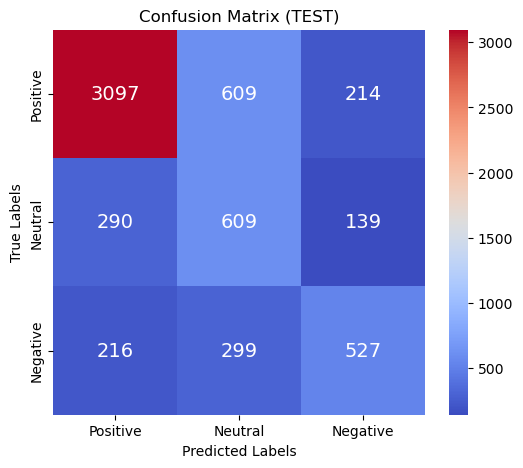

F1 Score (Weighted) (TEST): 0.7156
F1 Score (Negative) (TEST): 0.5484
AUC (TEST): 0.8196
Accuracy (TEST): 0.7055
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82      3920
           1       0.40      0.59      0.48      1038
           2       0.60      0.51      0.55      1042

    accuracy                           0.71      6000
   macro avg       0.62      0.63      0.62      6000
weighted avg       0.74      0.71      0.72      6000



Confusion Matrix (TRAIN) for new Iterated Model:


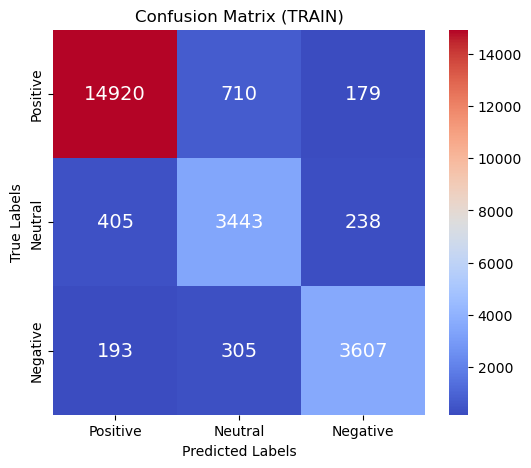

F1 Score (Weighted) (TRAIN): 0.9164
F1 Score (Negative) (TRAIN): 0.8874
AUC (TRAIN): 0.9718
Accuracy (TRAIN): 0.9154


Classification Report (TRAIN):
               precision    recall  f1-score   support

           0       0.96      0.94      0.95     15809
           1       0.77      0.84      0.81      4086
           2       0.90      0.88      0.89      4105

    accuracy                           0.92     24000
   macro avg       0.88      0.89      0.88     24000
weighted avg       0.92      0.92      0.92     24000



In [22]:

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=["Positive", "Neutral", "Negative"], 
                yticklabels=["Positive", "Neutral", "Negative"], annot_kws={"size": 14})
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()

# Evaluate the TUNED model on the TEST set
y_pred_test = second_model.predict(X_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion Matrix (TEST)
cm_test = confusion_matrix(y_test_classes, y_pred_test_classes)
print("Confusion Matrix (TEST) for New Iterated Model:")
plot_confusion_matrix(cm_test, "Confusion Matrix (TEST)")

# F1 Scores (TEST)
f1_weighted_test = f1_score(y_test_classes, y_pred_test_classes, average="weighted")
f1_neg_test = f1_score(y_test_classes, y_pred_test_classes, average="weighted", labels=[2])
print(f"F1 Score (Weighted) (TEST): {f1_weighted_test:.4f}")
print(f"F1 Score (Negative) (TEST): {f1_neg_test:.4f}")

# Multi-class AUC-ROC (TEST)
roc_auc_test = roc_auc_score(y_test, y_pred_test, multi_class="ovr")
print(f"AUC (TEST): {roc_auc_test:.4f}")

# Accuracy (TEST)
accuracy_test = accuracy_score(y_test_classes, y_pred_test_classes)
print(f"Accuracy (TEST): {accuracy_test:.4f}")

print("Classification Report:\n", classification_report(y_test_classes, y_pred_test_classes))

print("\n" + "="*50 + "\n")

# Evaluate the new iteration model on the TRAINING set
y_pred_train = second_model.predict(X_train)
y_pred_train_classes = np.argmax(y_pred_train, axis=1)
y_train_classes = np.argmax(y_train, axis=1)

# Confusion Matrix (TRAIN)
cm_train = confusion_matrix(y_train_classes, y_pred_train_classes)
print("Confusion Matrix (TRAIN) for new Iterated Model:")
plot_confusion_matrix(cm_train, "Confusion Matrix (TRAIN)")

# F1 Scores (TRAIN)
f1_weighted_train = f1_score(y_train_classes, y_pred_train_classes, average="weighted")
f1_neg_train = f1_score(y_train_classes, y_pred_train_classes, average="weighted", labels=[2])
print(f"F1 Score (Weighted) (TRAIN): {f1_weighted_train:.4f}")
print(f"F1 Score (Negative) (TRAIN): {f1_neg_train:.4f}")

# Multi-class AUC-ROC (TRAIN)
roc_auc_train = roc_auc_score(y_train, y_pred_train, multi_class="ovr")
print(f"AUC (TRAIN): {roc_auc_train:.4f}")

# Accuracy (TRAIN)
accuracy_train = accuracy_score(y_train_classes, y_pred_train_classes)
print(f"Accuracy (TRAIN): {accuracy_train:.4f}")

print("\n" + "="*50 + "\n")

print("Classification Report (TRAIN):\n", classification_report(y_train_classes, y_pred_train_classes))

## The 3rd model gives the best test accuracy which is the reason we will choose it as our final model

## LIME ANALYSIS

In [23]:
# Create a LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, 
    mode="classification", 
    feature_names=list(tokenizer.word_index.keys())
)

# Explain a single prediction
exp = explainer.explain_instance(X_test[0], second_model.predict, num_features=10)
exp.show_in_notebook()